**Insight: Overtime Strongly Influences Attrition**<br>
Target Variable: Attrition<br>
Model: Random Forest<br>
Input: Full dataset (excluding target column)

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load the preprocessed dataset
df = pd.read_csv("cleaned_employee_data.csv")

In [5]:
# Define features and target
X = df.drop(columns=['Attrition'])
y = df['Attrition']

In [6]:
# Scale Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
# Train-Test Split, stratified sampling
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

In [13]:
# Train Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [15]:
# Make Predictions
y_pred_rf = rf_model.predict(X_test)
y_probs_rf = rf_model.predict_proba(X_test)[:, 1]

Accuracy: 83.67%
Precision: 47.37%
Recall: 12.68%
F1 Score: 20.00%



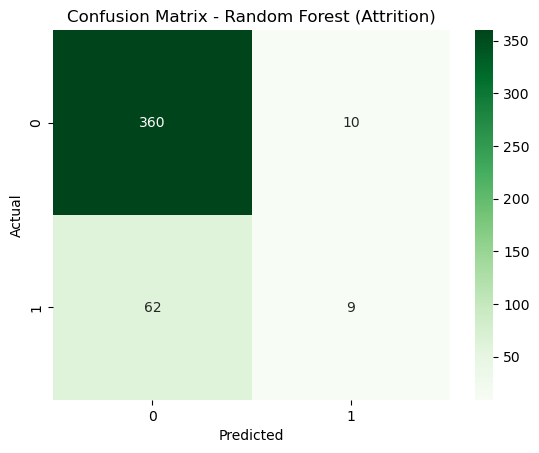

True Positives: 9
True Negatives: 360
False Positives: 10
False Negatives: 62


In [17]:
# Evaluate the Model
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf)*100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred_rf)*100:.2f}%")
print(f"Recall: {recall_score(y_test, y_pred_rf)*100:.2f}%")
print(f"F1 Score: {f1_score(y_test, y_pred_rf)*100:.2f}%")
print()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Random Forest (Attrition)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# TP, TN, FP, FN
tn, fp, fn, tp = cm.ravel()
print(f"True Positives: {tp}")
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")

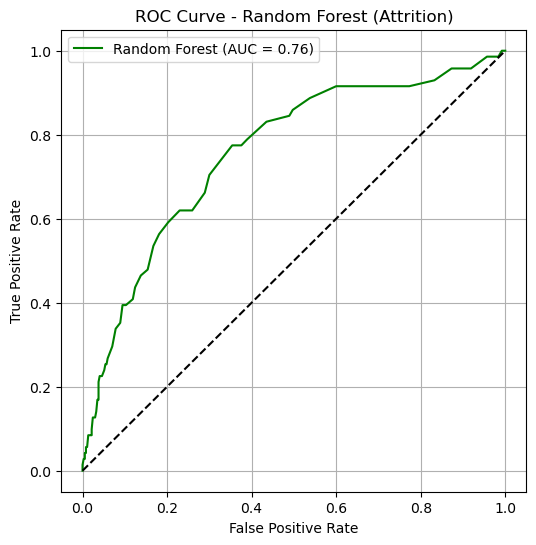

In [19]:
# ROC Curve & AUC
fpr, tpr, _ = roc_curve(y_test, y_probs_rf)
auc = roc_auc_score(y_test, y_probs_rf)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc:.2f})", color='green')
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve - Random Forest (Attrition)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_24568\3692531277.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances.head(10), x='Importance', y='Feature', palette='Greens_r')


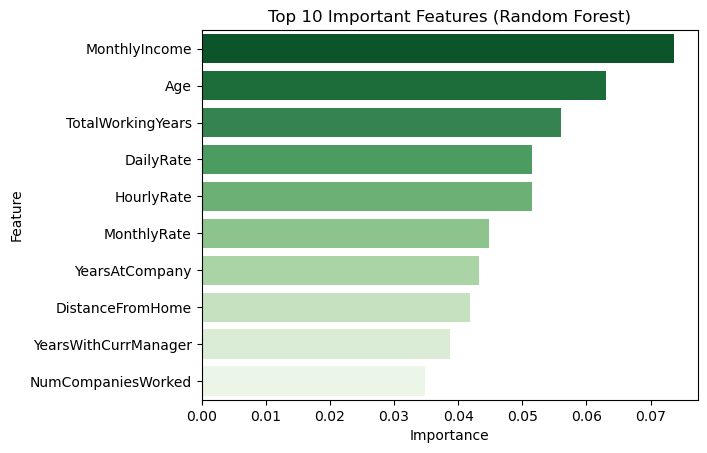

In [21]:
# Feature Importance
# Show top features that affect attrition
importances = pd.DataFrame({
    'Feature': df.drop(columns='Attrition').columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

sns.barplot(data=importances.head(10), x='Importance', y='Feature', palette='Greens_r')
plt.title("Top 10 Important Features (Random Forest)")
plt.show()